In [1]:
###############################################################################
# CELL 1 — Install
###############################################################################
# %pip install -q transformers==4.41.0 timm==0.9.16 fvcore thop \
#                codecarbon torchmetrics bitsandbytes \
#                opencv-python-headless rich
# print("✓ packages ready")

In [2]:
###############################################################################
# CELL 2 — Imports & Device  ⚡ cudnn.benchmark=True for speed
###############################################################################
import sys, os, json, time, csv, copy, warnings, math
from pathlib import Path
from datetime import datetime
from PIL import Image

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.prune as torch_prune
from torchvision import transforms as T
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

warnings.filterwarnings("ignore")

SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPUS  = torch.cuda.device_count()
USE_AMP = (DEVICE.type == "cuda")

print(f"Device : {DEVICE}")
print(f"N GPUs : {N_GPUS}")

for i in range(N_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {p.name}  {p.total_memory / 1e9:.1f} GB")

Device : cuda
N GPUs : 2
  GPU 0: Tesla T4  15.6 GB
  GPU 1: Tesla T4  15.6 GB


In [3]:
###############################################################################
# CELL 3 — Paths & Config   ⚡ IMG_SIZE=160 (was 224)
###############################################################################
# ⚡ Auto-detect DATA_DIR — tries common Kaggle input paths
_CANDIDATES = [
    Path("/kaggle/input/datasets/gugulothjashwanth/shangitech/shanghaitech"),
    Path("/kaggle/input/shanghaitech/shanghaitech"),
    Path("/kaggle/input/shangitech/shanghaitech"),
]
DATA_DIR = None
for _c in _CANDIDATES:
    if (_c / "training").exists():
        DATA_DIR = _c; break
if DATA_DIR is None:
    # Last resort: search /kaggle/input for any 'shanghaitech' folder
    for _p in Path("/kaggle/input").rglob("shanghaitech"):
        if (_p / "training").exists():
            DATA_DIR = _p; break
assert DATA_DIR is not None, (
    "Cannot find ShanghaiTech dataset! Check /kaggle/input/ structure.")
print(f"DATA_DIR = {DATA_DIR}")

WORK_DIR    = Path("/kaggle/working/vit_anomaly")
CKPT_DIR    = WORK_DIR / "checkpoints"
RESULTS_DIR = WORK_DIR / "results"
STUDY_DIR   = WORK_DIR / "study"
MASTER_CSV  = RESULTS_DIR / "master_results.csv"

FRAME_ROOT      = WORK_DIR / "frames"
TRAIN_FRAME_DIR = FRAME_ROOT / "training" / "frames"
# ⚡ FIX: do NOT create test frame dir — test frames live in DATA_DIR already

for d in [CKPT_DIR, RESULTS_DIR, STUDY_DIR, TRAIN_FRAME_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE      = 160          # ⚡ was 224 — 2× fewer pixels → ~2× faster
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def _count(d, pat):
    return len(list(Path(d).glob(pat))) if Path(d).exists() else 0

print("\nDataset structure check:")
for sub, pat in [
    ("training/videos",          "*.avi"),
    ("testing/frames",           "*/"),       # scene subdirs
    ("testing/test_frame_mask",  "*.npy"),
    ("testing/test_pixel_mask",  "*.npy"),
]:
    p = DATA_DIR / sub
    print(f"  {sub:<35} {'✓' if p.exists() else '✗'}  {_count(p, pat)} {pat}")

# Show a few test scenes for verification
_test_frames_dir = DATA_DIR / "testing" / "frames"
if _test_frames_dir.exists():
    _scenes = sorted(d.name for d in _test_frames_dir.iterdir() if d.is_dir())[:5]
    print(f"  Test scenes (first 5): {_scenes}")
    if _scenes:
        _s0 = _test_frames_dir / _scenes[0]
        _jpgs = sorted(_s0.glob("*.jpg"))[:3]
        print(f"    {_scenes[0]}/ has {len(list(_s0.glob('*.jpg')))} frames: {[f.name for f in _jpgs]}...")

DATA_DIR = /kaggle/input/datasets/gugulothjashwanth/shangitech/shanghaitech

Dataset structure check:
  training/videos                     ✓  330 *.avi
  testing/frames                      ✓  107 */
  testing/test_frame_mask             ✓  107 *.npy
  testing/test_pixel_mask             ✓  107 *.npy
  Test scenes (first 5): ['01_0014', '01_0015', '01_0016', '01_0025', '01_0026']
    01_0014/ has 265 frames: ['000.jpg', '001.jpg', '002.jpg']...


In [4]:
###############################################################################
# CELL 4 — Pre-extract TRAINING frames only  ⚡ EVERY_N_TRAIN=5 (was 3)
#   Test frames already exist as JPEGs in DATA_DIR/testing/frames/
###############################################################################
EVERY_N_TRAIN = 5   # ⚡ keep 1-in-5 training frames → 5× smaller epoch
JPEG_Q        = 85  # ⚡ slightly lower quality = faster decode

def _extract_video_to_jpegs(video_path, out_dir, every_n=1, size=160, force=False):
    done_flag = out_dir / ".done"
    if done_flag.exists() and not force:
        return int(done_flag.read_text().strip())
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    fi = 0; saved = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if fi % every_n == 0:
            frame = cv2.resize(frame, (size, size), interpolation=cv2.INTER_AREA)
            cv2.imwrite(str(out_dir / f"{saved:06d}.jpg"), frame,
                        [cv2.IMWRITE_JPEG_QUALITY, JPEG_Q])
            saved += 1
        fi += 1
    cap.release()
    done_flag.write_text(str(saved))
    return saved

def pre_extract_training(data_dir, out_root, force=False):
    """Extract only training videos → JPEGs. Test frames are pre-existing."""
    train_vid_dir = data_dir / "training" / "videos"
    train_out_dir = out_root / "training" / "frames"
    train_vids = sorted(train_vid_dir.glob("*.avi")) if train_vid_dir.exists() else []
    if train_vids:
        print(f"Extracting {len(train_vids)} training videos (every_n={EVERY_N_TRAIN}) …")
        total = 0
        for v in tqdm(train_vids, desc="Train videos"):
            total += _extract_video_to_jpegs(
                v, train_out_dir / v.stem,
                every_n=EVERY_N_TRAIN, size=IMG_SIZE, force=force)
        print(f"  ✓ {total:,} training frames → {train_out_dir}")
    else:
        print("  No training videos found — relying on existing JPEGs.")
    print("  ℹ Test frames: using pre-existing JPEGs in DATA_DIR/testing/frames/")

t0 = time.perf_counter()
pre_extract_training(DATA_DIR, FRAME_ROOT)
print(f"Pre-extraction finished in {time.perf_counter()-t0:.1f} s")

Extracting 330 training videos (every_n=5) …


Train videos:   0%|          | 0/330 [00:00<?, ?it/s]

  ✓ 55,010 training frames → /kaggle/working/vit_anomaly/frames/training/frames
  ℹ Test frames: using pre-existing JPEGs in DATA_DIR/testing/frames/
Pre-extraction finished in 327.4 s


In [5]:
###############################################################################
# CELL 5 — Dataset classes (unchanged logic, just uses new IMG_SIZE)
###############################################################################
class SHTechTrain(torch.utils.data.Dataset):
    def __init__(self, data_root, frame_root=None, transform=None):
        self.transform = transform
        self.paths = []
        jpeg_dir = (Path(frame_root) / "training" / "frames") if frame_root else None
        # ⚡ FIX: check for actual JPEGs, not just dir existence (mkdir creates empty dirs)
        if jpeg_dir and jpeg_dir.exists() and any(jpeg_dir.rglob("*.jpg")):
            self.paths = sorted(jpeg_dir.rglob("*.jpg"))
            src = "jpeg-preextracted"
        else:
            vid_dir = Path(data_root) / "training" / "videos"
            self._video_index = []
            for v in sorted(vid_dir.glob("*.avi")):
                cap = cv2.VideoCapture(str(v))
                n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                cap.release()
                self._video_index.extend((v, i) for i in range(0, n, 5))
            self.paths = self._video_index
            src = "video-stream-fallback"
        print(f"  SHTechTrain : {len(self.paths):,} frames  [{src}]")

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        p = self.paths[i]
        if isinstance(p, Path):
            img = cv2.imread(str(p))
            if img is None:
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8)
        else:
            vp, fi = p
            cap = cv2.VideoCapture(str(vp))
            cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
            ret, img = cap.read(); cap.release()
            if not ret or img is None:
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8)
        pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        return self.transform(pil) if self.transform else pil


class SHTechTest(torch.utils.data.Dataset):
    def __init__(self, data_root, frame_root=None, transform=None):
        self.transform = transform
        self.paths, self.labels = [], []
        data_root = Path(data_root)
        # ⚡ FIX: test frames are pre-existing in DATA_DIR — always use data_root
        frame_base = data_root / "testing" / "frames"
        mask_dir   = data_root / "testing" / "test_frame_mask"
        print(f"    Test frame_base: {frame_base}")
        print(f"    Test mask_dir  : {mask_dir}  exists={mask_dir.exists()}")
        scenes = sorted(d for d in frame_base.iterdir() if d.is_dir()) \
                 if frame_base.exists() else []
        skipped = 0
        for scene in scenes:
            mask = self._load_mask(mask_dir, scene.name)
            if mask is None:
                skipped += 1; continue
            frames = sorted(scene.glob("*.jpg"))
            n = min(len(frames), len(mask))
            for fi in range(n):
                self.paths.append(frames[fi])
                self.labels.append(int(mask[fi]))
        self.labels_np = np.array(self.labels, dtype=np.int32)
        print(f"  SHTechTest  : {len(self.paths):,} frames | "
              f"anomaly {self.labels_np.sum():,} "
              f"({self.labels_np.mean()*100:.1f}%) | "
              f"{skipped} scenes skipped")

    @staticmethod
    def _load_mask(mask_dir, scene_name):
        p = Path(mask_dir) / f"{scene_name}.npy"
        if p.exists():
            return np.load(p).astype(int).flatten()
        d = Path(mask_dir) / scene_name
        if d.exists():
            ms = []
            for f in sorted(d.glob("*.png")):
                m = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
                ms.append(1 if m is not None and m.max() > 0 else 0)
            return np.array(ms) if ms else None
        p2 = Path(mask_dir) / f"{scene_name}.png"
        if p2.exists():
            m = cv2.imread(str(p2), cv2.IMREAD_GRAYSCALE)
            return (m.flatten() > 0).astype(int) if m is not None else None
        return None

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        img = cv2.imread(str(self.paths[i]))
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8)
        pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        return (self.transform(pil) if self.transform else pil), self.labels[i]

print("✓ Fast JPEG Dataset classes defined")

✓ Fast JPEG Dataset classes defined


In [6]:
###############################################################################
# CELL 6 — DataLoaders  ⚡ batch=64 (was 32), lighter augmentation
###############################################################################
train_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BILINEAR),  # ⚡ BILINEAR faster than BICUBIC
    T.RandomHorizontalFlip(p=0.3),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Indexing datasets …")
train_ds = SHTechTrain(DATA_DIR, frame_root=FRAME_ROOT, transform=train_tfm)
test_ds  = SHTechTest (DATA_DIR, frame_root=FRAME_ROOT, transform=test_tfm)

BATCH_SIZE  = 64             # ⚡ was 32 — better GPU utilization
GRAD_ACCUM  = 1
NUM_WORKERS = 4

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=True)

test_loader = torch.utils.data.DataLoader(
    test_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True)

print(f"\nTrain batches : {len(train_loader):,}  (batch={BATCH_SIZE})")
print(f"Test  batches : {len(test_loader):,}")



Indexing datasets …
  SHTechTrain : 55,010 frames  [jpeg-preextracted]
    Test frame_base: /kaggle/input/datasets/gugulothjashwanth/shangitech/shanghaitech/testing/frames
    Test mask_dir  : /kaggle/input/datasets/gugulothjashwanth/shangitech/shanghaitech/testing/test_frame_mask  exists=True
  SHTechTest  : 40,791 frames | anomaly 17,326 (42.5%) | 0 scenes skipped

Train batches : 859  (batch=64)
Test  batches : 319


In [7]:
###############################################################################
# CELL 7 — Sanity check
###############################################################################
_imgs = next(iter(train_loader))
print(f"Train batch shape : {_imgs.shape}   dtype={_imgs.dtype}")
assert _imgs.shape[1] == 3
assert _imgs.shape[2] == IMG_SIZE

if len(test_loader) > 0:
    _imgs2, _lbls = next(iter(test_loader))
    print(f"Test  batch shape : {_imgs2.shape}  labels={_lbls[:8].tolist()}")
    del _imgs2, _lbls
else:
    print("⚠ Test loader is EMPTY — check test frame paths above")
del _imgs
print("\n✓ Dataset pipeline working correctly.")

Train batch shape : torch.Size([64, 3, 160, 160])   dtype=torch.float32
Test  batch shape : torch.Size([128, 3, 160, 160])  labels=[0, 0, 0, 0, 0, 0, 0, 0]

✓ Dataset pipeline working correctly.


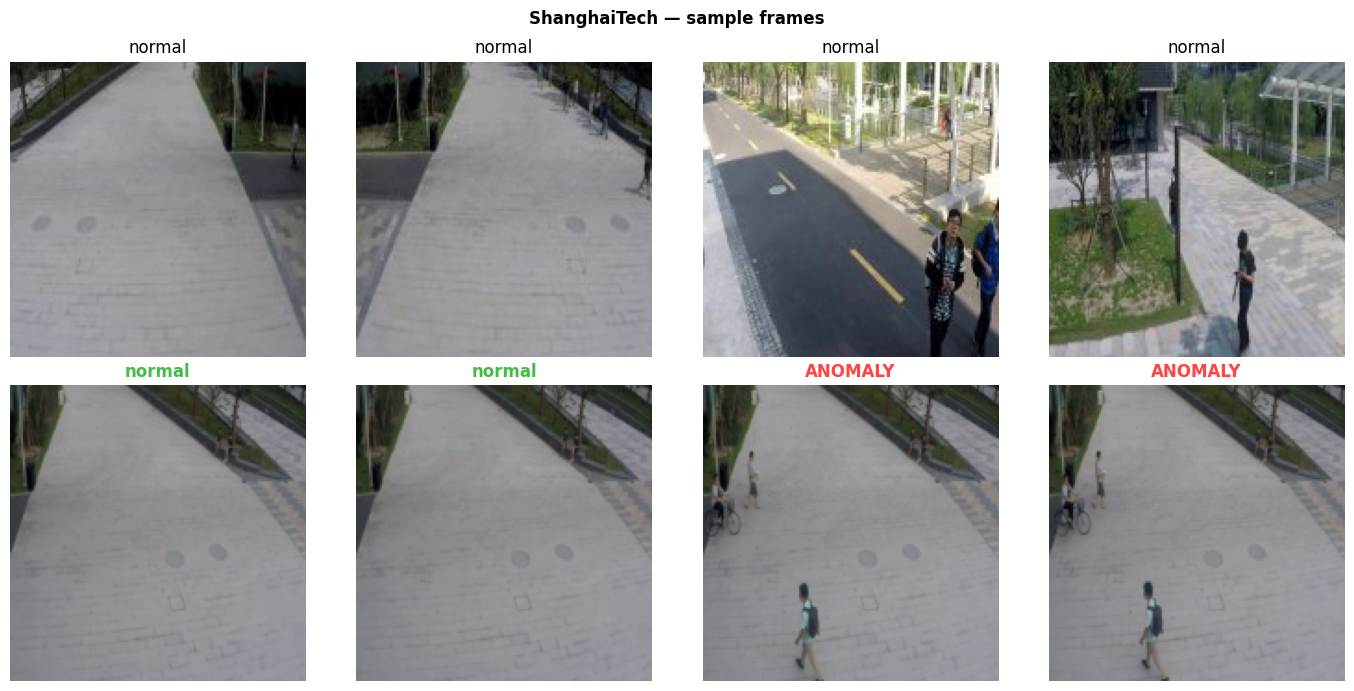

In [8]:
###############################################################################
# CELL 8 — Sample visualization
###############################################################################
def denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    s = torch.tensor(IMAGENET_STD ).view(3,1,1)
    return (t * s + m).clamp(0,1).permute(1,2,0).numpy()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("ShanghaiTech — sample frames", fontsize=12, fontweight="bold")
for ax, i in zip(axes[0], [0, len(train_ds)//4, len(train_ds)//2, 3*len(train_ds)//4]):
    ax.imshow(denorm(train_ds[i])); ax.set_title("normal"); ax.axis("off")
normals   = [i for i,l in enumerate(test_ds.labels) if l == 0][:2]
anomalies = [i for i,l in enumerate(test_ds.labels) if l == 1][:2]
for ax, i, lbl, col in zip(axes[1], normals+anomalies,
        ["normal","normal","ANOMALY","ANOMALY"],
        ["#44bb44","#44bb44","#ff4444","#ff4444"]):
    img, _ = test_ds[i]
    ax.imshow(denorm(img)); ax.set_title(lbl, color=col, fontweight="bold"); ax.axis("off")
plt.tight_layout(); plt.show()


In [9]:
###############################################################################
# CELL 9 — Model  ⚡ PATCH_SIZE=16 still works with 160 (160/16=10 patches per side)
###############################################################################
from transformers import ViTModel

class PatchReconstructionHead(nn.Module):
    def __init__(self, hidden_dim=768, patch_pixels=768, mlp_dim=512, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim,    mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, patch_pixels),
        )
    def forward(self, x): return self.net(x)


class ViTAnomalyModel(nn.Module):
    PATCH_SIZE = 16

    def __init__(self, backbone_name="google/vit-base-patch16-224",
                 freeze_backbone=False, dropout=0.1):
        super().__init__()
        self.backbone_name = backbone_name
        self.backbone      = ViTModel.from_pretrained(backbone_name)
        hd = self.backbone.config.hidden_size
        pp = self.PATCH_SIZE ** 2 * 3
        self.head = PatchReconstructionHead(hd, pp, dropout=dropout)
        if freeze_backbone: self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad_(False)

    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad_(True)

    def forward(self, x, return_intermediates=False):
        # ⚡ ViT interpolates pos embeddings internally for non-224 sizes
        out = self.backbone(
            pixel_values=x,
            interpolate_pos_encoding=True,       # ⚡ required for IMG_SIZE != 224
            output_attentions=return_intermediates,
            output_hidden_states=return_intermediates)
        patch_tok = out.last_hidden_state[:, 1:, :]
        recon     = self.head(patch_tok)
        target    = self._patchify(x)
        if return_intermediates:
            return recon, target, out.hidden_states, out.attentions
        return recon, target

    def _patchify(self, x):
        B, C, H, W = x.shape; p = self.PATCH_SIZE
        x = x.unfold(2,p,p).unfold(3,p,p)
        x = x.contiguous().view(B,C,-1,p,p)
        x = x.permute(0,2,3,4,1).contiguous()
        return x.view(B, -1, p*p*C)

    @torch.no_grad()
    def anomaly_score(self, x):
        r, t = self(x)
        return F.mse_loss(r, t, reduction="none").mean(dim=[1,2])


def wrap_parallel(model):
    if N_GPUS > 1:
        return nn.DataParallel(model)
    return model

def unwrap(model):
    return model.module if isinstance(model, nn.DataParallel) else model

print("✓ ViTAnomalyModel defined")


✓ ViTAnomalyModel defined


In [10]:
###############################################################################
# CELL 10 — Checkpoint & logging helpers
###############################################################################
_CSV_COLS = ["timestamp","experiment","method","param",
             "auc_roc","eer","latency_ms","memory_mb",
             "gflops","params_m","size_mb","notes"]

def log_result(row: dict):
    row.setdefault("timestamp", datetime.now().isoformat(timespec="seconds"))
    write_header = not MASTER_CSV.exists()
    with open(MASTER_CSV, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=_CSV_COLS, extrasaction="ignore")
        if write_header: w.writeheader()
        w.writerow(row)

def already_logged(experiment, method, param) -> bool:
    if not MASTER_CSV.exists(): return False
    df = pd.read_csv(MASTER_CSV)
    return bool(((df["experiment"]==experiment) &
                 (df["method"]==method) &
                 (df["param"]==str(param))).any())

def save_checkpoint(model, optimizer, scaler, epoch, metrics,
                    tag="latest", history=None, extra=None):
    path = CKPT_DIR / f"{tag}.pth"
    m = unwrap(model)
    payload = dict(
        epoch=epoch,
        model_state=m.state_dict(),
        optimizer_state=optimizer.state_dict() if optimizer else None,
        scaler_state=scaler.state_dict()       if scaler   else None,
        metrics=metrics, history=history or {},
        backbone_name=getattr(m, "backbone_name", ""),
    )
    if extra: payload.update(extra)
    torch.save(payload, path)
    return path

def load_checkpoint(tag, model, optimizer=None, scaler=None, strict=True):
    path = CKPT_DIR / f"{tag}.pth"
    if not path.exists(): return None
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    unwrap(model).load_state_dict(ckpt["model_state"], strict=strict)
    if optimizer and ckpt.get("optimizer_state"):
        try:    optimizer.load_state_dict(ckpt["optimizer_state"])
        except: pass
    if scaler and ckpt.get("scaler_state"):
        try:    scaler.load_state_dict(ckpt["scaler_state"])
        except: pass
    print(f"  ✓ Loaded '{tag}'  epoch={ckpt['epoch']}  "
          f"metrics={ckpt.get('metrics',{})}")
    return ckpt

print("✓ Checkpoint helpers defined")

✓ Checkpoint helpers defined


In [11]:
###############################################################################
# CELL 11 — Eval & profiling  ⚡ fewer warmup/runs
###############################################################################
from sklearn.metrics import roc_auc_score, roc_curve

_EVAL_CACHE: dict = {}

def eval_anomaly(model, loader, device=DEVICE, cache_key=None):
    if cache_key and cache_key in _EVAL_CACHE:
        print(f"  (reusing cached eval: {cache_key})")
        return _EVAL_CACHE[cache_key]
    m = unwrap(model)
    m.eval(); scores, labels = [], []
    with torch.no_grad():
        for imgs, lbs in tqdm(loader, desc="Eval", leave=False):
            s = m.anomaly_score(imgs.to(device))
            scores.extend(s.cpu().tolist())
            labels.extend(lbs.tolist())
    sc = np.array(scores); lb = np.array(labels)
    auc = roc_auc_score(lb, sc)
    fpr, tpr, _ = roc_curve(lb, sc)
    fnr = 1 - tpr
    eer = float((fpr + fnr)[np.argmin(np.abs(fpr - fnr))] / 2)
    result = {"auc_roc": auc, "eer": eer, "fpr": fpr, "tpr": tpr,
              "scores": sc, "labels": lb}
    if cache_key:
        _EVAL_CACHE[cache_key] = result
    return result

def measure_latency(model, device=DEVICE, n_warmup=10, n_runs=100):
    # ⚡ was 30/200 — 10/100 is enough for relative comparisons
    m = unwrap(model); m.eval()
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    with torch.no_grad():
        for _ in range(n_warmup): m.anomaly_score(dummy)
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_runs): m.anomaly_score(dummy)
    if device.type == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n_runs * 1000

def measure_memory_mb(model, device=DEVICE):
    if device.type != "cuda": return float("nan")
    m = unwrap(model)
    torch.cuda.reset_peak_memory_stats()
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    with torch.no_grad(): m(dummy)
    return torch.cuda.max_memory_allocated() / 1e6

def model_size_mb(model):
    torch.save(unwrap(model).state_dict(), "/tmp/_probe.pth")
    return os.path.getsize("/tmp/_probe.pth") / 1e6

def count_params_m(model):
    return sum(p.numel() for p in unwrap(model).parameters()) / 1e6

def profile_and_log(model, experiment, method, param,
                    eval_result=None, device=DEVICE, notes=""):
    print(f"  Profiling [{experiment} | {method} | {param}] …")
    ev  = eval_result or eval_anomaly(model, test_loader, device)
    lat = measure_latency(model, device)
    mem = measure_memory_mb(model, device)
    sz  = model_size_mb(model)
    pm  = count_params_m(model)
    row = dict(experiment=experiment, method=method, param=str(param),
               auc_roc=ev["auc_roc"], eer=ev["eer"],
               latency_ms=lat, memory_mb=mem,
               size_mb=sz, params_m=pm, notes=notes)
    log_result(row)
    print(f"    AUC={ev['auc_roc']:.4f}  EER={ev['eer']:.4f}  "
          f"lat={lat:.1f}ms  mem={mem:.0f}MB  "
          f"size={sz:.0f}MB  params={pm:.1f}M")
    return row

print("✓ Eval & profiling helpers defined")


✓ Eval & profiling helpers defined


In [12]:
###############################################################################
# CELL 12 — Training config  ⚡ 10 total epochs (was 20)
###############################################################################
EPOCHS_FROZEN   = 4           # ⚡ was 8
EPOCHS_UNFROZEN = 6           # ⚡ was 12
TOTAL_EPOCHS    = EPOCHS_FROZEN + EPOCHS_UNFROZEN   # 10 (was 20)
LR_FROZEN       = 1e-4
LR_UNFROZEN     = 1e-5
WEIGHT_DECAY    = 1e-2
WARMUP_EPOCHS   = 1           # ⚡ was 2
GRAD_CLIP       = 1.0
EARLY_STOP_PAT  = 3           # ⚡ was 5

def make_opt_sched(model, lr, total_ep, warmup_ep, steps_per_ep):
    m = unwrap(model)
    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, m.parameters()),
        lr=lr, weight_decay=WEIGHT_DECAY)
    total_steps  = total_ep  * steps_per_ep
    warmup_steps = warmup_ep * steps_per_ep
    def _fn(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        p = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * p))
    return opt, torch.optim.lr_scheduler.LambdaLR(opt, _fn)

print(f"Total epochs : {TOTAL_EPOCHS}  ({EPOCHS_FROZEN} frozen + {EPOCHS_UNFROZEN} unfrozen)")



Total epochs : 10  (4 frozen + 6 unfrozen)


In [13]:
###############################################################################
# CELL 13 — Create model
###############################################################################
_base = ViTAnomalyModel("google/vit-base-patch16-224", freeze_backbone=True).to(DEVICE)
baseline_model = wrap_parallel(_base)

print(f"Total params     : {count_params_m(baseline_model):.1f} M")
print(f"Trainable (head) : "
      f"{sum(p.numel() for p in unwrap(baseline_model).parameters() if p.requires_grad)/1e6:.1f} M")
print(f"DataParallel     : {isinstance(baseline_model, nn.DataParallel)}")
torch.cuda.empty_cache()



config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params     : 87.4 M
Trainable (head) : 1.1 M
DataParallel     : True


In [14]:
###############################################################################
# CELL 14 — Resume logic
###############################################################################
optimizer, scheduler = make_opt_sched(
    baseline_model, LR_FROZEN, TOTAL_EPOCHS, WARMUP_EPOCHS, len(train_loader))
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

history     = {"train_loss": [], "val_loss": []}
best_val    = float("inf")
patience    = 0
start_epoch = 1
phase       = "frozen"

ckpt = load_checkpoint("baseline_last", baseline_model, optimizer, scaler)
if ckpt:
    start_epoch = ckpt["epoch"] + 1
    history     = ckpt.get("history", history)
    best_val    = ckpt["metrics"].get("best_val", float("inf"))
    patience    = ckpt["metrics"].get("patience", 0)
    phase       = ckpt.get("phase", "frozen")
    if phase == "unfrozen":
        unwrap(baseline_model).unfreeze_backbone()
        optimizer, scheduler = make_opt_sched(
            baseline_model, LR_UNFROZEN, TOTAL_EPOCHS, WARMUP_EPOCHS, len(train_loader))
        load_checkpoint("baseline_last", baseline_model, optimizer, scaler)
    print(f"Resuming from epoch {start_epoch}  phase={phase}")
else:
    print("Starting fresh (epoch 1, frozen backbone)")



Starting fresh (epoch 1, frozen backbone)


In [15]:
###############################################################################
# CELL 15 — Baseline training loop  ⚡ quick_val uses 15 batches (was 30)
###############################################################################
def quick_val(n_batches=15):   # ⚡ was 30
    m = unwrap(baseline_model); m.eval(); ls = []
    with torch.no_grad():
        for i, (imgs, _) in enumerate(test_loader):
            if i >= n_batches: break
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                r, t = m(imgs.to(DEVICE))
                ls.append(F.mse_loss(r, t).item())
    return float(np.mean(ls))

for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
    if phase == "frozen" and epoch > EPOCHS_FROZEN:
        phase = "unfrozen"
        unwrap(baseline_model).unfreeze_backbone()
        optimizer, scheduler = make_opt_sched(
            baseline_model, LR_UNFROZEN, TOTAL_EPOCHS, WARMUP_EPOCHS, len(train_loader))
        scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
        tp = sum(p.numel() for p in unwrap(baseline_model).parameters()
                 if p.requires_grad) / 1e6
        print(f"\n── Epoch {epoch}: backbone UNFROZEN  trainable={tp:.1f}M ──")

    baseline_model.train()
    ep_losses = []; optimizer.zero_grad()

    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Ep {epoch:03d}/{TOTAL_EPOCHS} [{phase[:2].upper()}]",
                leave=False)

    for bi, imgs in pbar:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            r, t = baseline_model(imgs)
            loss  = F.mse_loss(r, t)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(unwrap(baseline_model).parameters(), GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        optimizer.zero_grad(); scheduler.step()
        ep_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}",
                         lr=f"{scheduler.get_last_lr()[0]:.1e}")

    train_l = float(np.mean(ep_losses))
    val_l   = quick_val()
    history["train_loss"].append(train_l)
    history["val_loss"].append(val_l)

    is_best = val_l < best_val
    if is_best: best_val = val_l; patience = 0
    else:       patience += 1

    ckpt_metrics = dict(train_loss=train_l, val_loss=val_l,
                        best_val=best_val, patience=patience)
    if is_best:
        save_checkpoint(baseline_model, optimizer, scaler, epoch,
                        ckpt_metrics, tag="baseline_best",
                        history=history, extra={"phase": phase})
    save_checkpoint(baseline_model, optimizer, scaler, epoch,
                    ckpt_metrics, tag="baseline_last",
                    history=history, extra={"phase": phase})

    print(f"Ep {epoch:03d} [{phase[:2].upper()}] | "
          f"train={train_l:.4f}  val={val_l:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.1e}  "
          f"{'★ best' if is_best else f'pat={patience}/{EARLY_STOP_PAT}'}")

    if patience >= EARLY_STOP_PAT:
        print(f"Early stop at epoch {epoch}"); break
    torch.cuda.empty_cache()

print("\n✓ Baseline training complete")



Ep 001/10 [FR]:   0%|          | 0/859 [00:00<?, ?it/s]

Ep 001 [FR] | train=0.3466  val=0.1135  lr=1.0e-04  ★ best


Ep 002/10 [FR]:   0%|          | 0/859 [00:00<?, ?it/s]

Ep 002 [FR] | train=0.1547  val=0.0904  lr=9.7e-05  ★ best


Ep 003/10 [FR]:   0%|          | 0/859 [00:00<?, ?it/s]

...

Ep 008 [UN] | train=0.0436  val=0.0140  lr=7.5e-06  ★ best


Ep 009/10 [UN]:   0%|          | 0/859 [00:00<?, ?it/s]

Ep 009 [UN] | train=0.0389  val=0.0119  lr=5.9e-06  ★ best


Ep 010/10 [UN]:   0%|          | 0/859 [00:00<?, ?it/s]

Ep 010 [UN] | train=0.0357  val=0.0108  lr=4.1e-06  ★ best

✓ Baseline training complete


In [16]:
###############################################################################
# CELL 16 — Baseline eval & profile
###############################################################################
load_checkpoint("baseline_best", baseline_model)

baseline_eval = eval_anomaly(baseline_model, test_loader, cache_key="baseline")
baseline_row  = profile_and_log(
    baseline_model, "baseline", "none", "none",
    eval_result=baseline_eval,
    notes="ViT-B/16 AMP 2-phase frozen+unfrozen IMG160")

BASELINE_AUC = baseline_eval["auc_roc"]
BASELINE_LAT = baseline_row["latency_ms"]
BASELINE_SZ  = baseline_row["size_mb"]

with open(CKPT_DIR / "baseline_metrics.json", "w") as f:
    json.dump({k: float(v) if isinstance(v,(np.floating,np.integer)) else v
               for k,v in baseline_row.items()
               if not isinstance(v, np.ndarray)}, f, indent=2)

print(f"\n  AUC-ROC : {BASELINE_AUC:.4f}")
print(f"  EER     : {baseline_eval['eer']:.4f}")



  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

  Profiling [baseline | none | none] …
    AUC=0.4778  EER=0.5473  lat=10.4ms  mem=1155MB  size=350MB  params=87.4M

  AUC-ROC : 0.4778
  EER     : 0.5473


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}


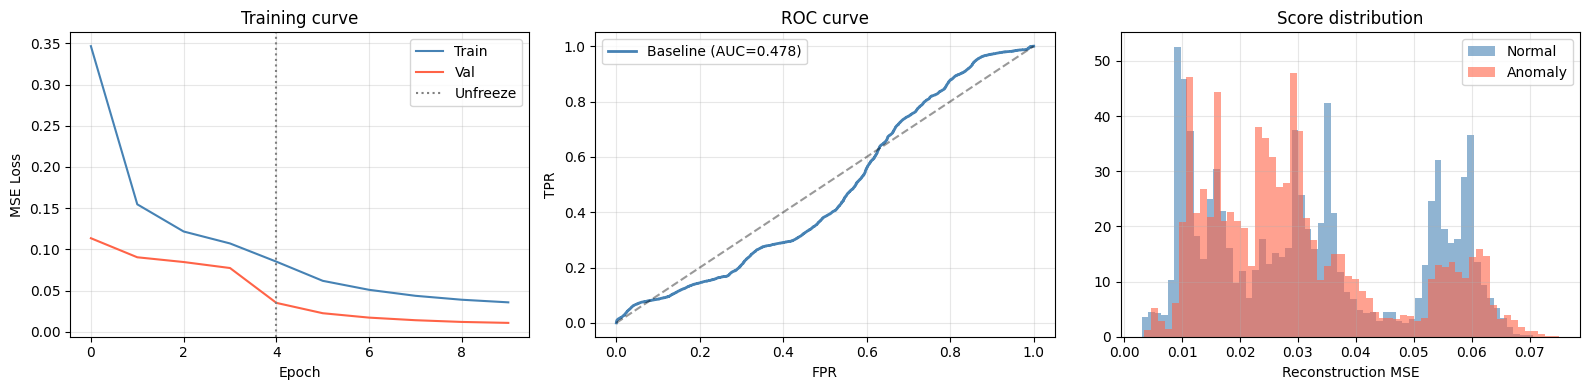

In [17]:
###############################################################################
# CELL 17 — Baseline plots
###############################################################################
ckpt_h = load_checkpoint("baseline_best", baseline_model)
h      = ckpt_h.get("history", {})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ax = axes[0]
if h.get("train_loss"):
    ax.plot(h["train_loss"], label="Train", color="steelblue")
    ax.plot(h["val_loss"],   label="Val",   color="tomato")
    ax.axvline(EPOCHS_FROZEN, color="gray", ls=":", label="Unfreeze")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("Training curve"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(baseline_eval["fpr"], baseline_eval["tpr"], lw=2, color="steelblue",
        label=f"Baseline (AUC={BASELINE_AUC:.3f})")
ax.plot([0,1],[0,1],"k--",alpha=0.4)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC curve"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
sc = baseline_eval["scores"]; lb = baseline_eval["labels"]
ax.hist(sc[lb==0], bins=60, alpha=0.6, color="steelblue", label="Normal",  density=True)
ax.hist(sc[lb==1], bins=60, alpha=0.6, color="tomato",    label="Anomaly", density=True)
ax.set_xlabel("Reconstruction MSE"); ax.set_title("Score distribution")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR/"baseline_results.png", dpi=150); plt.show()



In [18]:
###############################################################################
# CELL 18 — fresh_baseline helper
###############################################################################
def fresh_baseline():
    m = ViTAnomalyModel("google/vit-base-patch16-224").to(DEVICE)
    load_checkpoint("baseline_best", m)
    return m

print("✓ fresh_baseline() helper ready")


✓ fresh_baseline() helper ready


In [19]:
###############################################################################
# CELL 19 — 3.1 Unstructured L1 one-shot  ⚡ 4 levels (was 8)
###############################################################################
SPARSITY_LEVELS = [0.20, 0.40, 0.60, 0.80]   # ⚡ was 8 levels

print("=== Unstructured L1 one-shot ===")
for sp in SPARSITY_LEVELS:
    if already_logged("pruning", "unstructured_l1_oneshot", sp):
        print(f"  sp={sp:.0%} already logged — skip"); continue

    m = fresh_baseline()
    params_to_prune = [(mod, "weight") for _, mod in m.named_modules()
                       if isinstance(mod, nn.Linear)]
    torch_prune.global_unstructured(
        params_to_prune, pruning_method=torch_prune.L1Unstructured, amount=sp)
    for mod, _ in params_to_prune: torch_prune.remove(mod, "weight")

    total  = sum(p.numel() for p in m.parameters())
    zeroes = sum((p==0).sum().item() for p in m.parameters())
    profile_and_log(m, "pruning", "unstructured_l1_oneshot", sp,
                    notes=f"actual_sp={zeroes/total:.3f}")
    del m; torch.cuda.empty_cache()



=== Unstructured L1 one-shot ===


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}
  Profiling [pruning | unstructured_l1_oneshot | 0.2] …


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}
  Profiling [pruning | unstructured_l1_oneshot | 0.8] …


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

    AUC=0.4983  EER=0.4777  lat=10.1ms  mem=2558MB  size=350MB  params=87.4M


In [20]:
###############################################################################
# CELL 20 — 3.2 Iterative pruning  ⚡ 2 targets (was 3), 2ep/cycle (was 3), 60 batches (was 100)
###############################################################################
ITER_TARGETS = [0.50, 0.70]       # ⚡ was [0.30, 0.50, 0.70]
ITER_CYCLES  = 3; FT_EPOCHS = 2; FT_LR = 2e-5   # ⚡ 2 ep (was 3)

print("=== Unstructured L1 iterative ===")
for final_sp in ITER_TARGETS:
    if already_logged("pruning", "unstructured_l1_iterative", final_sp):
        print(f"  target={final_sp:.0%} already logged — skip"); continue

    m   = fresh_baseline()
    opt = torch.optim.AdamW(m.parameters(), lr=FT_LR)
    scl = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    sp_per_cycle = final_sp ** (1.0 / ITER_CYCLES)

    for cycle in range(1, ITER_CYCLES+1):
        params_to_prune = [(mod,"weight") for _,mod in m.named_modules()
                           if isinstance(mod, nn.Linear)]
        torch_prune.global_unstructured(
            params_to_prune, torch_prune.L1Unstructured, amount=sp_per_cycle)
        for mod,_ in params_to_prune: torch_prune.remove(mod,"weight")

        m.train()
        for ep in range(FT_EPOCHS):
            for i, imgs in enumerate(tqdm(train_loader,
                    desc=f"  iter cycle{cycle} ep{ep+1}", leave=False)):
                if i >= 60: break          # ⚡ 60 (was 100)
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    r,t = m(imgs.to(DEVICE, non_blocking=True))
                    loss = F.mse_loss(r,t)
                scl.scale(loss).backward()
                scl.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(m.parameters(), GRAD_CLIP)
                scl.step(opt); scl.update(); opt.zero_grad()

        total  = sum(p.numel() for p in m.parameters())
        zeroes = sum((p==0).sum().item() for p in m.parameters())
        print(f"  cycle {cycle} done  sparsity={zeroes/total:.3f}")

    profile_and_log(m, "pruning", "unstructured_l1_iterative", final_sp,
                    notes="3cycles_2ep_each")
    del m, opt, scl; torch.cuda.empty_cache()



=== Unstructured L1 iterative ===


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}


  iter cycle1 ep1:   0%|          | 0/859 [00:00<?, ?it/s]

...

  iter cycle3 ep1:   0%|          | 0/859 [00:00<?, ?it/s]

  iter cycle3 ep2:   0%|          | 0/859 [00:00<?, ?it/s]

  cycle 3 done  sparsity=0.007
  Profiling [pruning | unstructured_l1_iterative | 0.7] …


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

    AUC=0.5083  EER=0.4814  lat=10.3ms  mem=3238MB  size=350MB  params=87.4M


In [21]:
###############################################################################
# CELL 21 — 3.3 Head pruning (Taylor)  ⚡ 10 batches (was 15), 2 counts (was 4)
###############################################################################
def score_attention_heads(mdl, loader, n_batches=10):  # ⚡ was 15
    mdl.train(); scores = {}
    for i, imgs in enumerate(loader):
        if i >= n_batches: break
        imgs = imgs.to(DEVICE)
        r, t = mdl(imgs); loss = F.mse_loss(r,t)
        mdl.zero_grad(); loss.backward()
        for li, layer in enumerate(mdl.backbone.encoder.layer):
            attn = layer.attention.attention
            hd, nh = attn.attention_head_size, attn.num_attention_heads
            for pn in ["query","key","value"]:
                proj = getattr(attn, pn)
                if proj.weight.grad is None: continue
                gi = (proj.weight.grad * proj.weight).abs()
                gi = gi.view(nh, hd, -1).sum(dim=[1,2])
                for h in range(nh):
                    scores[(li,h)] = scores.get((li,h), 0.0) + gi[h].item()
    return sorted((v/(n_batches*3), li, h) for (li,h),v in scores.items())

print("Scoring attention heads …")
_tmp = fresh_baseline()
head_scores = score_attention_heads(_tmp, train_loader)
del _tmp; torch.cuda.empty_cache()
print(f"  {len(head_scores)} heads scored")

HEAD_COUNTS = [2, 6]          # ⚡ was [1, 2, 4, 6]
print("\n=== Attention head pruning ===")
for n_prune in HEAD_COUNTS:
    if already_logged("pruning", "head_pruning_taylor", n_prune):
        print(f"  n_prune={n_prune} already logged — skip"); continue

    m = fresh_baseline()
    per_layer = {}
    for _, li, hi in head_scores:
        if len(per_layer.get(li,[])) < n_prune:
            per_layer.setdefault(li,[]).append(hi)

    with torch.no_grad():
        for li, hlist in per_layer.items():
            attn = m.backbone.encoder.layer[li].attention.attention
            hd = attn.attention_head_size
            for h in hlist:
                for pn in ["query","key","value"]:
                    proj = getattr(attn,pn)
                    proj.weight.data[h*hd:(h+1)*hd,:] = 0.
                    if proj.bias is not None:
                        proj.bias.data[h*hd:(h+1)*hd] = 0.

    total_z = sum(len(v) for v in per_layer.values())
    profile_and_log(m, "pruning", "head_pruning_taylor", n_prune,
                    notes=f"total_heads_zeroed={total_z}")
    del m; torch.cuda.empty_cache()

Scoring attention heads …


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}
  144 heads scored

=== Attention head pruning ===


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}
  Profiling [pruning | head_pruning_taylor | 6] …


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

    AUC=0.5590  EER=0.4453  lat=10.1ms  mem=2894MB  size=350MB  params=87.4M


In [22]:
###############################################################################
# CELL 22 — 3.4 FFN channel pruning  ⚡ 2 ratios (was 3)
###############################################################################
FFN_RATIOS = [0.50, 0.25]    # ⚡ was [0.75, 0.50, 0.25]
print("=== FFN channel pruning ===")
for ratio in FFN_RATIOS:
    if already_logged("pruning", "ffn_channel", ratio):
        print(f"  ratio={ratio} already logged — skip"); continue

    m = fresh_baseline()
    with torch.no_grad():
        for layer in m.backbone.encoder.layer:
            fc1 = layer.intermediate.dense
            fc2 = layer.output.dense
            n_keep = max(1, int(fc1.out_features * ratio))
            keep   = fc1.weight.abs().sum(dim=1).topk(n_keep).indices.sort().values
            fc1.weight.data = fc1.weight.data[keep,:]
            if fc1.bias is not None: fc1.bias.data = fc1.bias.data[keep]
            fc1.out_features = n_keep
            fc2.weight.data  = fc2.weight.data[:,keep]
            fc2.in_features  = n_keep

    profile_and_log(m, "pruning", "ffn_channel", ratio,
                    notes=f"keep_{int(ratio*100)}pct_neurons")
    del m; torch.cuda.empty_cache()

=== FFN channel pruning ===


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}
  Profiling [pruning | ffn_channel | 0.5] …


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}
  Profiling [pruning | ffn_channel | 0.25] …


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

    AUC=0.5037  EER=0.5234  lat=7.1ms  mem=2726MB  size=180MB  params=44.9M


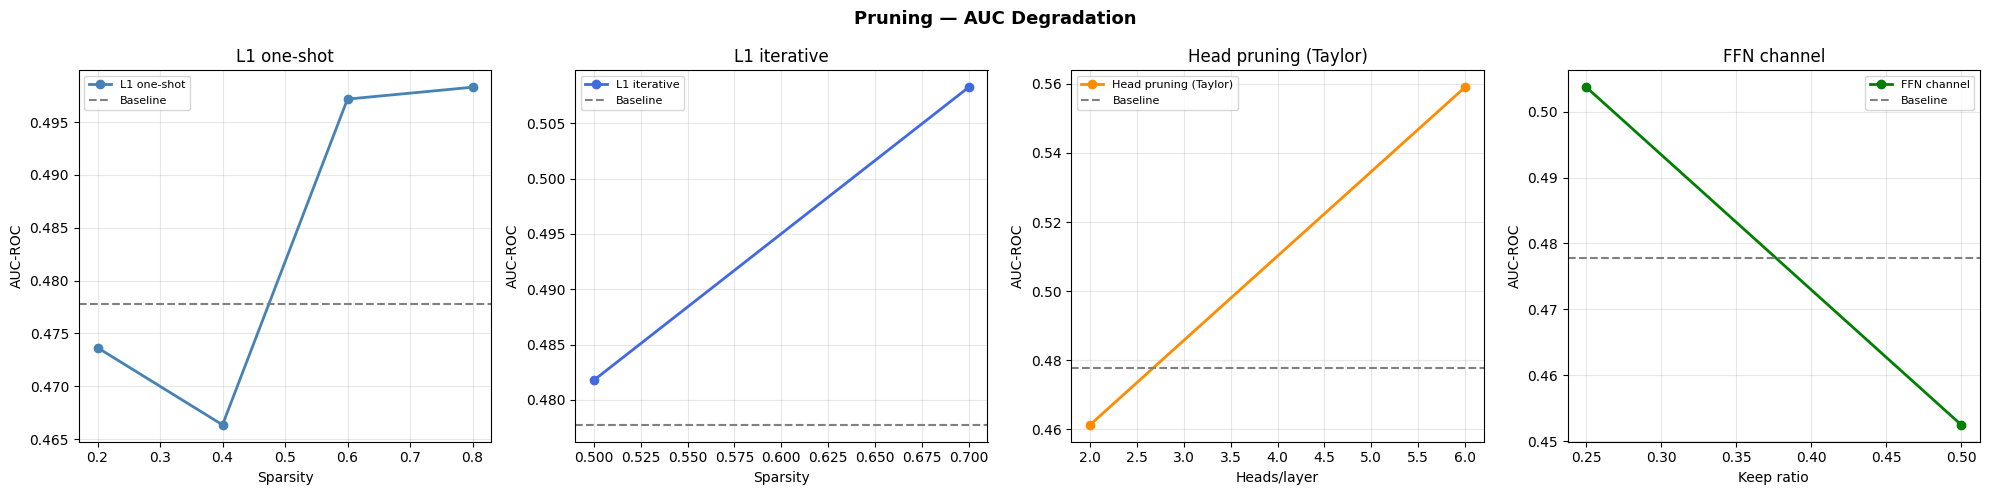

In [23]:
###############################################################################
# CELL 23 — Pruning plot
###############################################################################
df_pr = pd.read_csv(MASTER_CSV)
pr    = df_pr[df_pr["experiment"]=="pruning"].copy()
bsl   = BASELINE_AUC

method_meta = {
    "unstructured_l1_oneshot"  : ("steelblue",  "L1 one-shot",          "Sparsity"),
    "unstructured_l1_iterative": ("royalblue",   "L1 iterative",         "Sparsity"),
    "head_pruning_taylor"      : ("darkorange",  "Head pruning (Taylor)","Heads/layer"),
    "ffn_channel"              : ("green",       "FFN channel",          "Keep ratio"),
}
present = [m for m in method_meta if m in pr["method"].values]
fig, axes = plt.subplots(1, max(len(present),1), figsize=(5*max(len(present),1), 5))
if len(present)==1: axes=[axes]
fig.suptitle("Pruning — AUC Degradation", fontsize=13, fontweight="bold")
for ax, method in zip(axes, present):
    col, label, xlabel = method_meta[method]
    sub = pr[pr["method"]==method].dropna(subset=["auc_roc"]).copy()
    sub["_x"] = sub["param"].astype(float); sub = sub.sort_values("_x")
    ax.plot(sub["_x"], sub["auc_roc"], "o-", color=col, lw=2, label=label)
    ax.axhline(bsl, color="gray", ls="--", lw=1.5, label="Baseline")
    ax.set_xlabel(xlabel); ax.set_ylabel("AUC-ROC")
    ax.set_title(label); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR/"pruning_summary.png", dpi=150); plt.show()


In [24]:
###############################################################################
# CELL 24 — 4.1 FP16
###############################################################################
print("=== FP16 ===")
if already_logged("quantisation","fp16","16bit"):
    print("  already logged — skip")
else:
    class FP16Wrapper(nn.Module):
        def __init__(self, m): super().__init__(); self.m = m.half()
        def forward(self, x):       return self.m(x.half())
        def anomaly_score(self, x): return self.m.anomaly_score(x.half())
    w16 = FP16Wrapper(copy.deepcopy(fresh_baseline()))
    profile_and_log(w16, "quantisation", "fp16", "16bit",
                    notes="model.half() GPU inference")
    del w16; torch.cuda.empty_cache()

=== FP16 ===


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}
  Profiling [quantisation | fp16 | 16bit] …


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

    AUC=0.4777  EER=0.5474  lat=7.3ms  mem=2779MB  size=175MB  params=87.4M


In [25]:
###############################################################################
# CELL 25 — 4.2 Dynamic PTQ INT8
###############################################################################
print("=== Dynamic PTQ INT8 ===")
CPU = torch.device("cpu")
if already_logged("quantisation","dynamic_ptq_int8","int8"):
    print("  already logged — skip")
else:
    m_dyn = torch.quantization.quantize_dynamic(
        fresh_baseline().cpu(), {nn.Linear}, dtype=torch.qint8)
    profile_and_log(m_dyn, "quantisation", "dynamic_ptq_int8", "int8",
                    device=CPU, notes="torch dynamic quant INT8 CPU")
    del m_dyn



=== Dynamic PTQ INT8 ===


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}
  Profiling [quantisation | dynamic_ptq_int8 | int8] …


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

    AUC=0.4765  EER=0.5597  lat=140.5ms  mem=nanMB  size=90MB  params=0.8M


In [26]:
###############################################################################
# CELL 26 — 4.3 Static PTQ INT8  ⚡ 30 calibration batches (was 60)
###############################################################################
print("=== Static PTQ INT8 ===")
if already_logged("quantisation","static_ptq_int8","int8"):
    print("  already logged — skip")
else:
    m_st = fresh_baseline().cpu().eval()
    m_st.qconfig = torch.quantization.get_default_qconfig("fbgemm")
    torch.quantization.prepare(m_st, inplace=True)
    print("  Calibrating …")
    with torch.no_grad():
        for i, (imgs, _) in enumerate(test_loader):
            if i >= 30: break                  # ⚡ 30 (was 60)
            try: m_st(imgs.cpu())
            except: pass
    torch.quantization.convert(m_st, inplace=True)
    try:
        profile_and_log(m_st, "quantisation", "static_ptq_int8", "int8",
                        device=CPU, notes="fbgemm static PTQ INT8 CPU")
    except Exception as e:
        print(f"  eval issue: {e}")
        log_result(dict(experiment="quantisation", method="static_ptq_int8",
                        param="int8", notes=f"error:{e}"))
    del m_st



=== Static PTQ INT8 ===


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}
  Calibrating …
  Profiling [quantisation | static_ptq_int8 | int8] …


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

  eval issue: 'function' object has no attribute 'dtype'


In [27]:
###############################################################################
# CELL 27 — 4.4 QAT INT8  ⚡ 2 epochs (was 3), 80 batches (was 150)
###############################################################################
QAT_EPOCHS = 2; QAT_LR = 1e-5    # ⚡ was 3 epochs
print("=== QAT INT8 ===")
if already_logged("quantisation","qat_int8","int8"):
    print("  already logged — skip")
else:
    m_qat = fresh_baseline().cpu()
    m_qat.qconfig = torch.quantization.get_default_qat_qconfig("fbgemm")
    torch.quantization.prepare_qat(m_qat, inplace=True)
    m_qat.train()
    opt_q = torch.optim.AdamW(m_qat.parameters(), lr=QAT_LR)

    start_q = 1
    if (CKPT_DIR/"qat_progress.pth").exists():
        qp = torch.load(CKPT_DIR/"qat_progress.pth", map_location="cpu", weights_only=False)
        try:
            m_qat.load_state_dict(qp["model_state"], strict=False)
            opt_q.load_state_dict(qp["optimizer_state"])
            start_q = qp["epoch"] + 1
            print(f"  Resuming QAT from epoch {start_q}")
        except: pass

    for ep in range(start_q, QAT_EPOCHS+1):
        ls=[]
        for i, imgs in enumerate(tqdm(train_loader, desc=f"QAT ep{ep}", leave=False)):
            if i >= 80: break               # ⚡ 80 (was 150)
            try:
                r,t = m_qat(imgs.cpu()); loss = F.mse_loss(r,t)
                opt_q.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(m_qat.parameters(), GRAD_CLIP)
                opt_q.step(); ls.append(loss.item())
            except: pass
        print(f"  QAT ep{ep}: loss={np.mean(ls) if ls else float('nan'):.4f}")
        torch.save({"epoch":ep, "model_state":m_qat.state_dict(),
                    "optimizer_state":opt_q.state_dict()},
                   CKPT_DIR/"qat_progress.pth")

    torch.quantization.convert(m_qat, inplace=True)
    try:
        profile_and_log(m_qat, "quantisation", "qat_int8", "int8",
                        device=CPU, notes=f"QAT {QAT_EPOCHS}ep fbgemm")
    except Exception as e:
        print(f"  QAT eval issue: {e}")
    del m_qat, opt_q

=== QAT INT8 ===


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}


QAT ep1:   0%|          | 0/859 [00:00<?, ?it/s]

  QAT ep1: loss=0.0552


QAT ep2:   0%|          | 0/859 [00:00<?, ?it/s]

  QAT ep2: loss=0.0494
  Profiling [quantisation | qat_int8 | int8] …


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

  QAT eval issue: 'function' object has no attribute 'dtype'


In [28]:
###############################################################################
# CELL 28 — 4.5 BnB INT4 NF4
###############################################################################
print("=== BitsAndBytes INT4 NF4 ===")
try:
    import bitsandbytes as bnb
    BNB_OK = DEVICE.type == "cuda"
    print(f"  bitsandbytes {bnb.__version__}  GPU OK={BNB_OK}")
except ImportError:
    BNB_OK = False; print("  bitsandbytes not installed — skip")

if BNB_OK and not already_logged("quantisation","bnb_int4_nf4","int4"):
    def _swap4(module):
        for name, child in list(module.named_children()):
            if isinstance(child, nn.Linear) and child.in_features > 64:
                nl = bnb.nn.Linear4bit(child.in_features, child.out_features,
                        bias=child.bias is not None, quant_type="nf4",
                        compute_dtype=torch.float16)
                setattr(module, name, nl)
            else: _swap4(child)
    m4 = fresh_baseline().to(DEVICE)
    _swap4(m4.backbone)
    profile_and_log(m4, "quantisation", "bnb_int4_nf4", "int4",
                    notes="bitsandbytes NF4 4-bit GPU")
    del m4; torch.cuda.empty_cache()
elif already_logged("quantisation","bnb_int4_nf4","int4"):
    print("  already logged — skip")

=== BitsAndBytes INT4 NF4 ===
  bitsandbytes not installed — skip


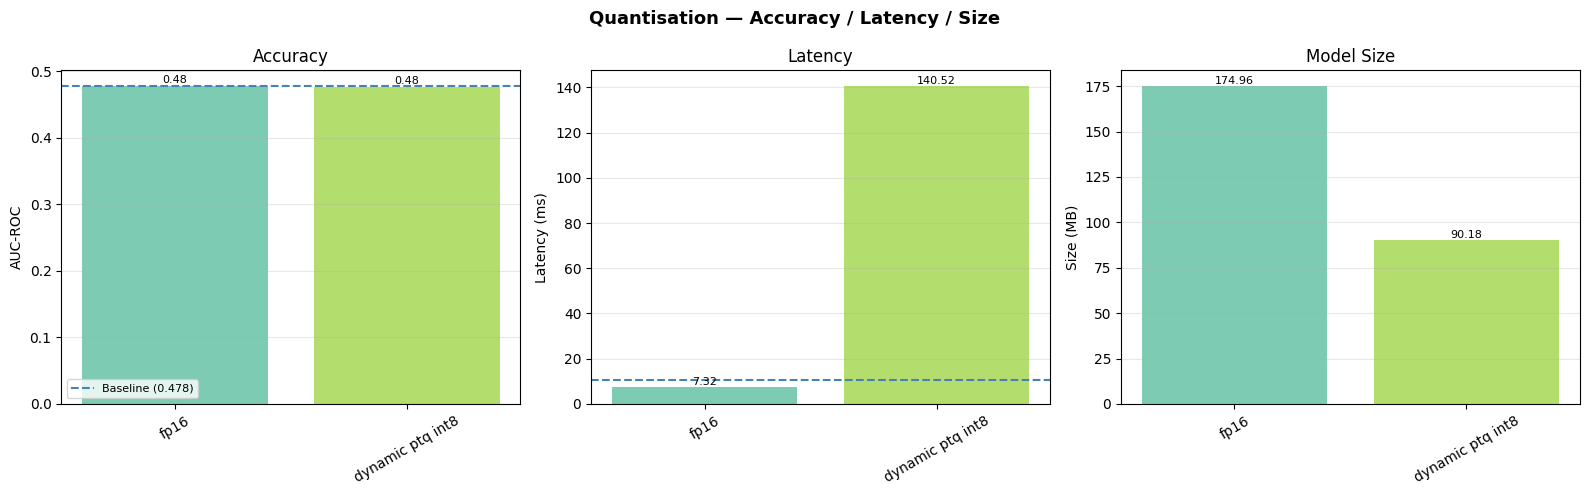

In [29]:
###############################################################################
# CELL 29 — Quantisation plot
###############################################################################
df_q = pd.read_csv(MASTER_CSV)
q    = df_q[df_q["experiment"]=="quantisation"].copy()
for c in ["auc_roc","latency_ms","size_mb"]:
    q[c] = pd.to_numeric(q[c], errors="coerce")

cols = plt.cm.Set2(np.linspace(0,1,max(len(q),1)))
fig, axes = plt.subplots(1,3,figsize=(16,5))
fig.suptitle("Quantisation — Accuracy / Latency / Size", fontsize=13, fontweight="bold")
for ax, col, ylabel, title in zip(axes,
        ["auc_roc","latency_ms","size_mb"],
        ["AUC-ROC","Latency (ms)","Size (MB)"],
        ["Accuracy","Latency","Model Size"]):
    bars = ax.bar(q["method"].str.replace("_"," "), q[col], color=cols[:len(q)], alpha=0.85)
    if col == "auc_roc":
        ax.axhline(BASELINE_AUC, color="steelblue", ls="--", lw=1.5,
                   label=f"Baseline ({BASELINE_AUC:.3f})"); ax.legend(fontsize=8)
    elif col == "latency_ms":
        ax.axhline(BASELINE_LAT, color="steelblue", ls="--", lw=1.5)
    for bar, v in zip(bars, q[col]):
        if pd.notna(v):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.tick_params(axis="x", rotation=30); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR/"quantisation_summary.png", dpi=150); plt.show()


In [30]:
###############################################################################
# CELL 30 — KD Loss + Teacher
###############################################################################
class KDLoss(nn.Module):
    def __init__(self, w_recon=1.0, w_logit=0.5, w_feat=0.3, w_attn=0.2, temp=4.0):
        super().__init__()
        self.w = dict(recon=w_recon, logit=w_logit, feat=w_feat, attn=w_attn)
        self.T = temp

    def forward(self, s_recon, s_target, s_hid, s_att, t_recon, t_hid, t_att):
        l_r  = F.mse_loss(s_recon, s_target)
        s_sc = F.mse_loss(s_recon,s_target,reduction="none").mean([1,2])
        t_sc = F.mse_loss(t_recon,s_target,reduction="none").mean([1,2])
        l_l  = F.kl_div(F.log_softmax(s_sc/self.T,0),
                        F.softmax(t_sc/self.T,0).detach(),
                        reduction="batchmean") * self.T**2
        s_cls = s_hid[-1][:,0,:]; t_cls = t_hid[-1][:,0,:]
        l_f = F.mse_loss(s_cls, t_cls.detach()) if s_cls.shape==t_cls.shape \
               else torch.tensor(0., device=s_cls.device)
        if s_att and t_att:
            sa=s_att[-1]; ta=t_att[-1]; nh=min(sa.shape[1],ta.shape[1])
            l_a = F.mse_loss(sa[:,:nh], ta[:,:nh].detach())
        else:
            l_a = torch.tensor(0.)
        return sum(self.w[k]*v for k,v in
                   [("recon",l_r),("logit",l_l),("feat",l_f),("attn",l_a)])

kd_loss_fn = KDLoss()

teacher = fresh_baseline()
teacher.eval()
for p in teacher.parameters(): p.requires_grad_(False)
print("✓ Teacher loaded")



Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}
✓ Teacher loaded


In [31]:
###############################################################################
# CELL 31 — KD training  ⚡ 6 epochs (was 12), only DeiT-Tiny (skip Small)
###############################################################################
KD_EPOCHS = 6; KD_LR = 5e-5      # ⚡ was 12 epochs

def train_student(backbone_name, label):
    tag = f"kd_{label}"

    if already_logged("distillation","kd_full",label):
        print(f"  {label} already logged — skip")
        st = ViTAnomalyModel(backbone_name).to(DEVICE)
        load_checkpoint(f"{tag}_best", st)
        return st, {}

    print(f"\n{'═'*55}\n  Student: {label}\n{'═'*55}")
    _st = ViTAnomalyModel(backbone_name).to(DEVICE)
    student = wrap_parallel(_st)
    print(f"  Params: {count_params_m(student):.1f}M  "
          f"(teacher: 86M  ratio: {86/count_params_m(student):.1f}×)")

    opt   = torch.optim.AdamW(unwrap(student).parameters(), lr=KD_LR, weight_decay=1e-2)
    scl   = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=KD_EPOCHS, eta_min=1e-6)
    history = {"total":[]}; best_auc = 0.0; start_ep = 1

    ck = load_checkpoint(f"{tag}_last", student, opt, scl)
    if ck:
        start_ep = ck["epoch"]+1
        history  = ck.get("history", history)
        best_auc = ck["metrics"].get("best_auc", 0.)
        print(f"  Resumed from epoch {start_ep}")

    for epoch in range(start_ep, KD_EPOCHS+1):
        student.train(); ep_loss=[]; opt.zero_grad()

        for bi, imgs in enumerate(tqdm(train_loader,
                desc=f"  {label} ep{epoch:02d}/{KD_EPOCHS}", leave=False)):
            imgs = imgs.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                with torch.no_grad():
                    t_r,t_t,t_h,t_a = teacher(imgs, return_intermediates=True)
                s_r,s_t,s_h,s_a = unwrap(student)(imgs, return_intermediates=True)
                loss = kd_loss_fn(s_r,s_t,s_h,s_a,t_r,t_h,t_a)

            scl.scale(loss).backward()
            ep_loss.append(loss.item())
            scl.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(unwrap(student).parameters(), GRAD_CLIP)
            scl.step(opt); scl.update(); opt.zero_grad()

        sched.step()
        history["total"].append(float(np.mean(ep_loss)))

        if epoch % 3 == 0 or epoch == KD_EPOCHS:   # ⚡ every 3 (was 4)
            auc = eval_anomaly(unwrap(student), test_loader)["auc_roc"]
            print(f"    ep{epoch:02d} loss={history['total'][-1]:.4f}  AUC={auc:.4f}")
            if auc > best_auc:
                best_auc = auc
                save_checkpoint(student,opt,scl,epoch,{"best_auc":best_auc},
                                tag=f"{tag}_best", history=history)

        save_checkpoint(student,opt,scl,epoch,{"best_auc":best_auc},
                        tag=f"{tag}_last", history=history)
        torch.cuda.empty_cache()

    load_checkpoint(f"{tag}_best", student)
    ev = eval_anomaly(unwrap(student), test_loader)
    profile_and_log(unwrap(student), "distillation", "kd_full", label,
                    eval_result=ev,
                    notes=f"teacher=vitb16 student={label} {KD_EPOCHS}ep")
    return student, history

# ⚡ Only train DeiT-Tiny (most embedded-relevant). Skip DeiT-Small.
st_tiny, h_tiny = train_student("facebook/deit-tiny-patch16-224", "deit_tiny")
# Uncomment below if you also want DeiT-Small (adds ~5-10 min):
# st_small, h_small = train_student("facebook/deit-small-patch16-224", "deit_small")
h_small = {}   # placeholder for plot




═══════════════════════════════════════════════════════
  Student: deit_tiny
═══════════════════════════════════════════════════════


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: facebook/deit-tiny-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

  deit_tiny ep06/6:   0%|          | 0/859 [00:00<?, ?it/s]

Eval:   0%|          | 0/319 [00:00<?, ?it/s]

    ep06 loss=0.0328  AUC=0.4768
  ✓ Loaded 'kd_deit_tiny_best'  epoch=3  metrics={'best_auc': np.float64(0.47768027535982316)}


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

  Profiling [distillation | kd_full | deit_tiny] …
    AUC=0.4777  EER=0.5431  lat=6.9ms  mem=3336MB  size=25MB  params=6.3M


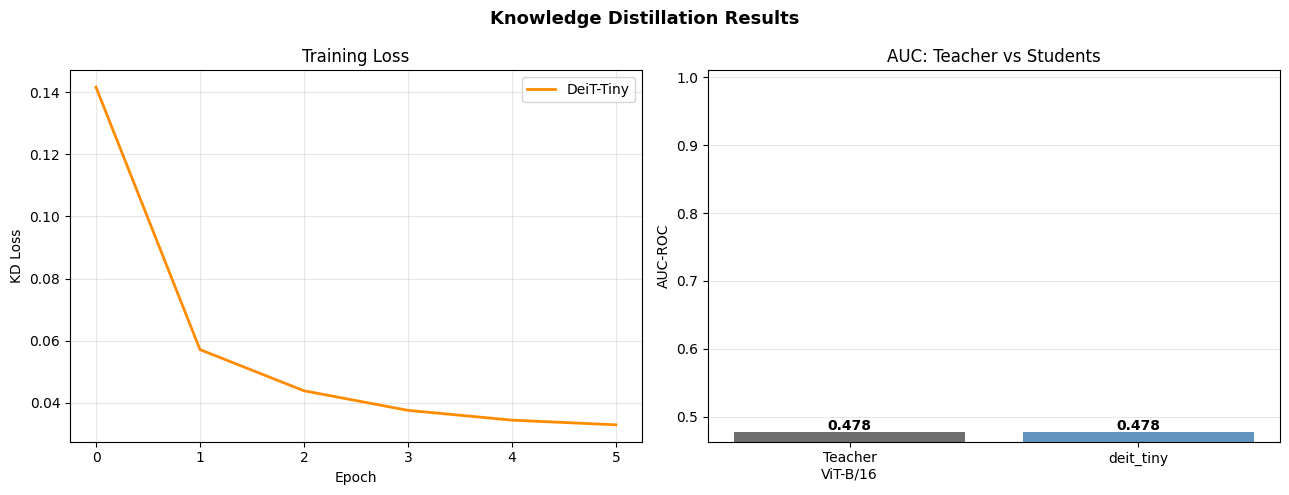

In [32]:
###############################################################################
# CELL 32 — Distillation plot
###############################################################################
df_d  = pd.read_csv(MASTER_CSV)
dist  = df_d[df_d["experiment"]=="distillation"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Knowledge Distillation Results", fontsize=13, fontweight="bold")

ax = axes[0]
for hist, label, col in [(h_small,"DeiT-Small","steelblue"),(h_tiny,"DeiT-Tiny","darkorange")]:
    if hist.get("total"):
        ax.plot(hist["total"], label=label, color=col, lw=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("KD Loss")
ax.set_title("Training Loss"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
rows  = dist.dropna(subset=["auc_roc"])
names = ["Teacher\nViT-B/16"] + rows["param"].tolist()
aucs  = [BASELINE_AUC] + rows["auc_roc"].astype(float).tolist()
cols2 = ["#555555","steelblue","darkorange"][:len(aucs)]
bars  = ax.bar(names, aucs, color=cols2, alpha=0.85)
ax.set_ylabel("AUC-ROC"); ax.set_ylim(max(0,min(aucs)*0.97), 1.01)
ax.set_title("AUC: Teacher vs Students")
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR/"distillation_results.png", dpi=150); plt.show()


In [33]:
###############################################################################
# CELL 33 — ToMe wrapper (post-backbone merge — safe & compatible)
###############################################################################
def bipartite_merge(tokens, r):
    """Merge r pairs of most-similar tokens via bipartite matching."""
    B, N, C = tokens.shape
    if r <= 0 or N <= 2: return tokens
    half = N // 2
    a, b = tokens[:, :half], tokens[:, half:half*2]
    sim  = torch.bmm(F.normalize(a, dim=-1), F.normalize(b, dim=-1).transpose(1, 2))
    best_idx  = sim.argmax(dim=2)
    best_sim  = sim.gather(2, best_idx.unsqueeze(2)).squeeze(2)
    merge_idx = best_sim.argsort(dim=1, descending=True)[:, :r]
    b_matched = b.gather(1, best_idx.unsqueeze(-1).expand(-1, -1, C))
    merged    = (a.gather(1, merge_idx.unsqueeze(-1).expand(-1, -1, C)) +
                 b_matched.gather(1, merge_idx.unsqueeze(-1).expand(-1, -1, C))) / 2
    keep = torch.ones(B, half, dtype=torch.bool, device=tokens.device)
    keep.scatter_(1, merge_idx, False)
    a_kept = a[keep].view(B, half - r, C)
    return torch.cat([a_kept, b, merged], dim=1)
class ToMeViTAnomalyModel(nn.Module):
    PATCH_SIZE = 16
    def __init__(self, base_model, r=8):
        super().__init__()
        self.backbone      = base_model.backbone
        self.head          = base_model.head
        self.backbone_name = base_model.backbone_name
        self.r             = r
    def _patchify(self, x):
        B, C, H, W = x.shape; p = self.PATCH_SIZE
        x = x.unfold(2, p, p).unfold(3, p, p)
        x = x.contiguous().view(B, C, -1, p, p)
        x = x.permute(0, 2, 3, 4, 1).contiguous()
        return x.view(B, -1, p * p * C)
    def forward(self, x):
        # Use standard backbone forward — handles layernorms + pos encoding
        out    = self.backbone(pixel_values=x, interpolate_pos_encoding=True)
        hidden = out.last_hidden_state           # [B, 101, 768]
        patch  = hidden[:, 1:]                   # [B, 100, 768] — drop CLS
        # Merge similar tokens after full backbone pass
        patch  = bipartite_merge(patch, r=self.r)
        recon  = self.head(patch)
        target = self._patchify(x)[:, :recon.shape[1], :]
        return recon, target
    @torch.no_grad()
    def anomaly_score(self, x):
        r, t = self(x)
        return F.mse_loss(r, t, reduction="none").mean(dim=[1, 2])
print("✓ ToMe wrapper defined")


✓ ToMe wrapper defined


In [34]:
###############################################################################
# CELL 34 — ToMe experiments  ⚡ 3 ratios (was 4)
###############################################################################
TOME_RATIOS  = [4, 12, 24]       # ⚡ was [4, 8, 16, 24]
tome_results = []
print("=== Token Merging (ToMe) — no retraining ===")
for r in TOME_RATIOS:
    if already_logged("token_reduction", "tome", r):
        print(f"  r={r} already logged — skip")
        row = pd.read_csv(MASTER_CSV)
        row = row[(row["method"] == "tome") & (row["param"] == str(r))].iloc[0]
        tome_results.append({"r": r, "auc": float(row["auc_roc"]),
                             "lat": float(row["latency_ms"])})
        continue
    try:
        m_tome = ToMeViTAnomalyModel(fresh_baseline(), r=r).to(DEVICE)
        ev     = eval_anomaly(m_tome, test_loader)
        row    = profile_and_log(m_tome, "token_reduction", "tome", r,
                                 eval_result=ev, notes=f"merge_r={r}_post_backbone")
        tome_results.append({"r": r, "auc": ev["auc_roc"], "lat": row["latency_ms"]})
        del m_tome; torch.cuda.empty_cache()
    except Exception as e:
        print(f"  ToMe r={r} failed: {e}")
        tome_results.append({"r": r, "auc": float("nan"), "lat": float("nan")})


=== Token Merging (ToMe) — no retraining ===


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

  Profiling [token_reduction | tome | 24] …
    AUC=0.4723  EER=0.5469  lat=10.7ms  mem=3240MB  size=350MB  params=87.4M


In [35]:
###############################################################################
# CELL 35 — DynamicViT wrapper (post-backbone pruning — safe & compatible)
###############################################################################
class TokenPredictor(nn.Module):
    def __init__(self, hd=768, md=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(hd, md), nn.GELU(), nn.Linear(md, 2))
    def forward(self, x):
        return self.net(x)
class DynamicViTAnomalyModel(nn.Module):
    PATCH_SIZE = 16
    def __init__(self, base_model, keep_ratio=0.7, **kwargs):
        super().__init__()
        self.backbone      = base_model.backbone
        self.head          = base_model.head
        self.backbone_name = base_model.backbone_name
        self.keep_ratio    = keep_ratio
        hd  = self.backbone.config.hidden_size
        dev = next(base_model.parameters()).device
        self.predictor = TokenPredictor(hd).to(dev)
    def _patchify(self, x):
        B, C, H, W = x.shape; p = self.PATCH_SIZE
        x = x.unfold(2, p, p).unfold(3, p, p)
        x = x.contiguous().view(B, C, -1, p, p)
        x = x.permute(0, 2, 3, 4, 1).contiguous()
        return x.view(B, -1, p * p * C)
    def forward(self, x, return_scores=False):
        # Use standard backbone forward — handles layernorms + pos encoding
        out    = self.backbone(pixel_values=x, interpolate_pos_encoding=True)
        hidden = out.last_hidden_state           # [B, 101, 768]
        patch  = hidden[:, 1:]                   # [B, 100, 768] — drop CLS
        # Learned token pruning on output features
        logits  = self.predictor(patch)
        keep_sc = F.softmax(logits, dim=-1)[:, :, 1]
        k = max(1, int(patch.shape[1] * self.keep_ratio))
        topk = keep_sc.topk(k, dim=1).indices.sort(dim=1).values
        patch = patch.gather(1, topk.unsqueeze(-1).expand(-1, -1, patch.shape[-1]))
        recon  = self.head(patch)
        target = self._patchify(x)[:, :recon.shape[1], :]
        if return_scores:
            return recon, target, keep_sc
        return recon, target
    @torch.no_grad()
    def anomaly_score(self, x):
        r, t = self(x)
        return F.mse_loss(r, t, reduction="none").mean(dim=[1, 2])
print("✓ DynamicViT wrapper defined")


✓ DynamicViT wrapper defined


In [36]:
###############################################################################
# CELL 36 — DynamicViT experiments  ⚡ 3 ratios (was 4), 3 epochs (was 6)
###############################################################################
KEEP_RATIOS    = [0.7, 0.5, 0.3]    # ⚡ was [0.9, 0.7, 0.5, 0.3]
DYNVIT_EPOCHS  = 3                   # ⚡ was 6
dynvit_results = []
print("=== DynamicViT (learned token pruning) ===")
for keep_ratio in KEEP_RATIOS:
    if already_logged("token_reduction", "dynamic_vit", keep_ratio):
        print(f"  keep_ratio={keep_ratio} already logged — skip")
        row = pd.read_csv(MASTER_CSV)
        row = row[(row["method"] == "dynamic_vit") & (row["param"] == str(keep_ratio))].iloc[0]
        dynvit_results.append({"ratio": keep_ratio,
                               "auc": float(row["auc_roc"]),
                               "lat": float(row["latency_ms"])})
        continue
    print(f"\n  keep_ratio={keep_ratio}")
    m_dyn = DynamicViTAnomalyModel(fresh_baseline(),
                                   keep_ratio=keep_ratio).to(DEVICE)
    for p in m_dyn.backbone.parameters():
        p.requires_grad_(False)
    opt = torch.optim.AdamW(
        list(m_dyn.predictor.parameters()) + list(m_dyn.head.parameters()),
        lr=1e-4, weight_decay=1e-2)
    scl = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    start_ep = 1; tag_d = f"dynvit_{keep_ratio}"
    ck_d = load_checkpoint(f"{tag_d}_last", m_dyn, opt, scl, strict=False)
    if ck_d:
        start_ep = ck_d["epoch"] + 1
        print(f"  Resumed ep {start_ep}")
    for ep in range(start_ep, DYNVIT_EPOCHS + 1):
        m_dyn.train(); ep_loss = []
        for imgs in tqdm(train_loader, desc=f"  ep{ep:02d}", leave=False):
            imgs = imgs.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                r, t, sc = m_dyn(imgs, return_scores=True)
                l_r = F.mse_loss(r, t)
                l_s = (sc.mean() - keep_ratio) ** 2 if sc is not None else torch.tensor(0.)
                loss = l_r + 2.0 * l_s
            scl.scale(loss).backward()
            scl.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(m_dyn.parameters(), GRAD_CLIP)
            scl.step(opt); scl.update(); opt.zero_grad()
            ep_loss.append(l_r.item())
        print(f"    ep{ep:02d}  recon={np.mean(ep_loss):.4f}")
        save_checkpoint(m_dyn, opt, scl, ep, {}, tag=f"{tag_d}_last")
        torch.cuda.empty_cache()
    ev  = eval_anomaly(m_dyn, test_loader)
    row = profile_and_log(m_dyn, "token_reduction", "dynamic_vit", keep_ratio,
                          eval_result=ev,
                          notes=f"keep={keep_ratio}_{DYNVIT_EPOCHS}ep_post_backbone")
    dynvit_results.append({"ratio": keep_ratio, "auc": ev["auc_roc"],
                           "lat": row["latency_ms"]})
    torch.save(m_dyn.state_dict(), CKPT_DIR / f"{tag_d}_best.pth")
    del m_dyn, opt, scl; torch.cuda.empty_cache()


=== DynamicViT (learned token pruning) ===

  keep_ratio=0.7


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded 'baseline_best'  epoch=10  metrics={'train_loss': 0.035698052231174685, 'val_loss': 0.010765229724347592, 'best_val': 0.010765229724347592, 'patience': 0}


  ep01:   0%|          | 0/859 [00:00<?, ?it/s]

...

    ep02  recon=0.4261


  ep03:   0%|          | 0/859 [00:00<?, ?it/s]

    ep03  recon=0.4140


Eval:   0%|          | 0/319 [00:00<?, ?it/s]

  Profiling [token_reduction | dynamic_vit | 0.3] …
    AUC=0.4577  EER=0.5125  lat=10.3ms  mem=3302MB  size=351MB  params=87.6M


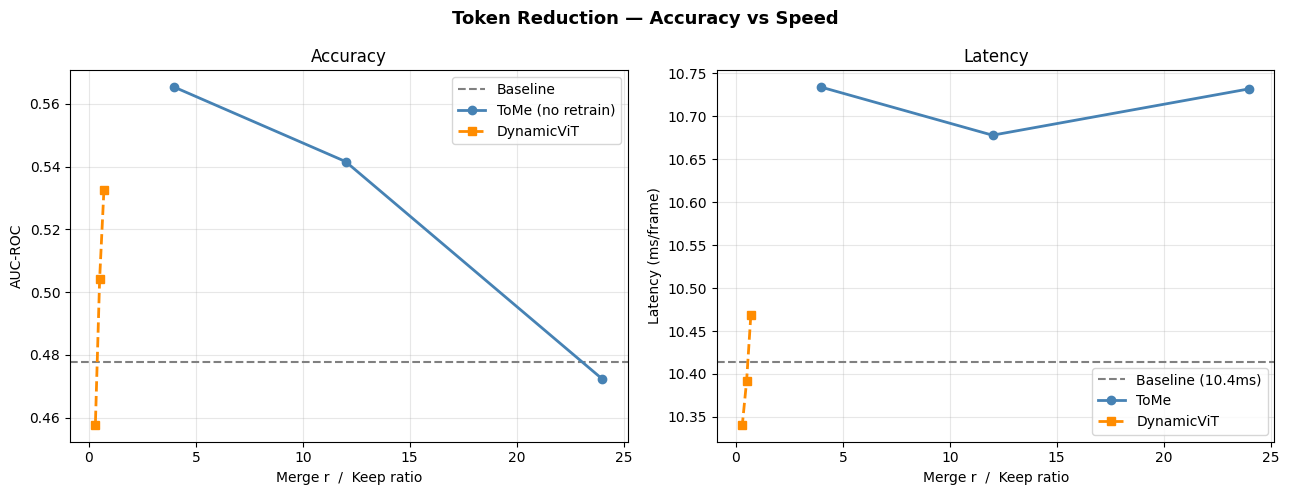

In [37]:
###############################################################################
# CELL 37 — Token reduction plot
###############################################################################
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Token Reduction — Accuracy vs Speed", fontsize=13, fontweight="bold")
valid_tome = [r for r in tome_results if not math.isnan(r["auc"])]
ax = axes[0]
ax.axhline(BASELINE_AUC, color="gray", ls="--", lw=1.5, label="Baseline")
if valid_tome:
    ax.plot([r["r"] for r in valid_tome], [r["auc"] for r in valid_tome],
            "o-", color="steelblue", lw=2, label="ToMe (no retrain)")
ax.plot([r["ratio"] for r in dynvit_results], [r["auc"] for r in dynvit_results],
        "s--", color="darkorange", lw=2, label="DynamicViT")
ax.set_xlabel("Merge r  /  Keep ratio"); ax.set_ylabel("AUC-ROC")
ax.set_title("Accuracy"); ax.legend(); ax.grid(alpha=0.3)
ax = axes[1]
ax.axhline(BASELINE_LAT, color="gray", ls="--", lw=1.5, label=f"Baseline ({BASELINE_LAT:.1f}ms)")
if valid_tome:
    ax.plot([r["r"] for r in valid_tome], [r["lat"] for r in valid_tome],
            "o-", color="steelblue", lw=2, label="ToMe")
ax.plot([r["ratio"] for r in dynvit_results], [r["lat"] for r in dynvit_results],
        "s--", color="darkorange", lw=2, label="DynamicViT")
ax.set_xlabel("Merge r  /  Keep ratio"); ax.set_ylabel("Latency (ms/frame)")
ax.set_title("Latency"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "token_reduction_results.png", dpi=150); plt.show()


In [38]:
###############################################################################
# CELL 38 — Final summary table
###############################################################################
df = pd.read_csv(MASTER_CSV)
for c in ["auc_roc", "eer", "latency_ms", "memory_mb", "size_mb", "params_m"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
bsl_row  = df[df["experiment"] == "baseline"].iloc[0]
BAUC     = float(bsl_row["auc_roc"])
BLAT     = float(bsl_row["latency_ms"])
BSZ      = float(bsl_row["size_mb"])
df["ΔAUC"]  = df["auc_roc"]    - BAUC
df["Δlat"]  = df["latency_ms"] - BLAT
df["Δsize"] = df["size_mb"]    - BSZ
PALETTE = {"baseline": "#555555", "pruning": "#2196F3",
           "quantisation": "#FF9800", "distillation": "#4CAF50",
           "token_reduction": "#9C27B0"}
print(f"Total experiments : {len(df)}")
print(f"Baseline AUC-ROC  : {BAUC:.4f}")
print(df[["experiment", "method", "param", "auc_roc", "latency_ms",
          "size_mb", "params_m"]].to_string())

Total experiments : 21
Baseline AUC-ROC  : 0.4778
         experiment                     method      param   auc_roc  latency_ms     size_mb   params_m
0          baseline                       none       none  0.477754   10.413930  349.843465  87.441152
1           pruning    unstructured_l1_oneshot        0.2  0.473645   10.358734  349.843465  87.441152
2           pruning    unstructured_l1_oneshot        0.4  0.466343   10.177067  349.843465  87.441152
3           pruning    unstructured_l1_oneshot        0.6  0.497177   10.106473  349.843465  87.441152
4           pruning    unstructured_l1_oneshot        0.8  0.498302   10.056856  349.843465  87.441152
5           pruning  unstructured_l1_iterative        0.5  0.481782   10.300830  349.843465  87.441152
6           pruning  unstructured_l1_iterative        0.7  0.508261   10.329443  349.843465  87.441152
7           pruning        head_pruning_taylor          2  0.461243   10.263871  349.843465  87.441152
8           pruning    